# Skin Cancer Classification — Advanced Ensemble Pipeline
### HAM10000 | EfficientNet-B3 + B5 Ensemble · ISIC Pretrained ViT · Multiclass→Binary
Target: AUC 0.95+

## 0. Install & mount Drive

In [1]:
!pip install torch torchvision timm --quiet
# timm gives us ISIC-compatible pretrained ViT weights

import subprocess
subprocess.run(["fusermount", "-u", "/drive"], capture_output=True)
from google.colab import drive
drive.mount('/drive')

Mounted at /drive


## 1. Download dataset

In [2]:
!pip install gdown kaggle --quiet

# Option A: Kaggle (recommended)
from google.colab import files
print("Upload your kaggle.json")
files.upload()
!mkdir -p ~/.kaggle && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/data/
!unzip -q /content/data/skin-cancer-mnist-ham10000.zip -d /content/data/HAM10000

# Merge image parts
import shutil, os
from pathlib import Path
IMG_DIR = Path("/content/data/HAM10000/images")
IMG_DIR.mkdir(exist_ok=True)
for part in ["HAM10000_images_part_1","ham10000_images_part_1","HAM10000_images_part_2","ham10000_images_part_2"]:
    src = Path(f"/content/data/HAM10000/{part}")
    if src.exists():
        for f in src.iterdir():
            shutil.copy(f, IMG_DIR / f.name)
        print(f"Copied {part}")
print("Total images:", len(list(IMG_DIR.iterdir())))

Upload your kaggle.json


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:49<00:00, 113MB/s]

Copied HAM10000_images_part_1
Copied ham10000_images_part_1
Copied HAM10000_images_part_2
Copied ham10000_images_part_2
Total images: 10015


## 2. Imports & reproducibility

In [3]:
import os, time, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from copy import deepcopy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast

import torchvision.transforms as T
from torchvision.models import (
    efficientnet_b3, EfficientNet_B3_Weights,
    efficientnet_b5, EfficientNet_B5_Weights
)
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.10.0+cu128


## 3. Config

In [4]:
DATA_DIR   = Path("/content/data/HAM10000")
METADATA   = DATA_DIR / "HAM10000_metadata.csv"
IMG_DIR    = DATA_DIR / "images"
OUTPUT_DIR = Path("/content/outputs")
CKPT_DIR   = Path("/drive/MyDrive/skin_cancer_checkpoints")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE     = 256
BATCH_SIZE   = 16
EPOCHS       = 40
LR_HEAD      = 5e-4
LR_BACKBONE  = 5e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1
THRESHOLD    = 0.40
TTA_PASSES   = 5
MIXUP_ALPHA  = 0.4
CUTMIX_ALPHA = 1.0
PATIENCE     = 10

# 7 classes for multiclass pretraining
ALL_CLASSES   = ["mel", "nv", "bcc", "akiec", "bkl", "df", "vasc"]
MALIGNANT     = ["mel", "bcc", "akiec"]
NUM_CLASSES   = len(ALL_CLASSES)

print("Config ready. Device:", DEVICE)

Config ready. Device: cuda


## 4. Load metadata

In [5]:
df = pd.read_csv(METADATA)
df["target"]     = df["dx"].apply(lambda x: 1 if x in MALIGNANT else 0)
df["class_idx"]  = df["dx"].apply(lambda x: ALL_CLASSES.index(x))  # multiclass label
df["image_path"] = df["image_id"].apply(lambda x: str(IMG_DIR / f"{x}.jpg"))
df = df[df["image_path"].apply(os.path.exists)].copy().reset_index(drop=True)

print("Dataset size:", len(df))
print("\nBinary:")
print(df["target"].value_counts().rename({0:"Benign",1:"Malignant"}))
print("\nMulticlass:")
print(df["dx"].value_counts())

Dataset size: 10015

Binary:
target
Benign       8061
Malignant    1954
Name: count, dtype: int64

Multiclass:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


## 5. Stratified split (70 / 15 / 15)

In [6]:
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["target"], random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["target"], random_state=SEED)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 7010 | Val: 1502 | Test: 1503


## 6. Transforms

In [7]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(30),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.2, scale=(0.02, 0.1)),
])
val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
tta_transforms = T.Compose([
    T.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    T.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
print("Transforms ready.")

Transforms ready.


## 7. Dataset & DataLoaders

In [8]:
class SkinDataset(Dataset):
    def __init__(self, dataframe, transform=None, mode="binary"):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
        self.mode      = mode  # "binary" or "multiclass"

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = int(row["class_idx"]) if self.mode == "multiclass" else int(row["target"])
        return img, label


def make_weighted_sampler(labels):
    class_counts   = np.bincount(labels)
    class_weights  = 1.0 / class_counts
    sample_weights = class_weights[labels]
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)


def make_loaders(mode="binary"):
    train_ds = SkinDataset(train_df, transform=train_transforms, mode=mode)
    val_ds   = SkinDataset(val_df,   transform=val_transforms,   mode=mode)
    test_ds  = SkinDataset(test_df,  transform=val_transforms,   mode=mode)
    labels   = train_df["class_idx"].values if mode == "multiclass" else train_df["target"].values
    sampler  = make_weighted_sampler(labels)
    tl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
    vl = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)
    tsl= DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)
    return tl, vl, tsl

print("Dataset classes ready.")

Dataset classes ready.


## 8. Model definitions — B3, B5, and ISIC ViT

In [9]:
# ── EfficientNet-B3 (binary head)
class EfficientNetB3Binary(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        base = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_features = base.classifier[1].in_features
        self.backbone   = base.features
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 512), nn.BatchNorm1d(512), nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.BatchNorm1d(128), nn.SiLU(), nn.Dropout(dropout/2),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.classifier(self.pool(self.backbone(x))).squeeze(1)
    def get_param_groups(self, lr_backbone, lr_head):
        return [{"params": self.backbone.parameters(), "lr": lr_backbone},
                {"params": self.pool.parameters(),     "lr": lr_backbone},
                {"params": self.classifier.parameters(),"lr": lr_head}]


# ── EfficientNet-B5 (binary head)
class EfficientNetB5Binary(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()
        base = efficientnet_b5(weights=EfficientNet_B5_Weights.IMAGENET1K_V1)
        in_features = base.classifier[1].in_features
        self.backbone   = base.features
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 512), nn.BatchNorm1d(512), nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.BatchNorm1d(128), nn.SiLU(), nn.Dropout(dropout/2),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.classifier(self.pool(self.backbone(x))).squeeze(1)
    def get_param_groups(self, lr_backbone, lr_head):
        return [{"params": self.backbone.parameters(), "lr": lr_backbone},
                {"params": self.pool.parameters(),     "lr": lr_backbone},
                {"params": self.classifier.parameters(),"lr": lr_head}]


# ── EfficientNet-B5 multiclass (7 classes) — for multiclass pretraining
class EfficientNetB5Multiclass(nn.Module):
    def __init__(self, num_classes=7, dropout=0.4):
        super().__init__()
        base = efficientnet_b5(weights=EfficientNet_B5_Weights.IMAGENET1K_V1)
        in_features = base.classifier[1].in_features
        self.backbone   = base.features
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 512), nn.BatchNorm1d(512), nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.BatchNorm1d(128), nn.SiLU(), nn.Dropout(dropout/2),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.pool(self.backbone(x)))
    def get_param_groups(self, lr_backbone, lr_head):
        return [{"params": self.backbone.parameters(), "lr": lr_backbone},
                {"params": self.pool.parameters(),     "lr": lr_backbone},
                {"params": self.classifier.parameters(),"lr": lr_head}]


# ── ISIC ViT — uses timm's vit_base pretrained on broader medical/natural data
class ISICViT(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        # eva02_small is pretrained on large-scale data, works well for medical imaging
        self.backbone = timm.create_model(
            "eva02_small_patch14_336.mim_in22k_ft_in1k",
            pretrained=True,
            num_classes=0,   # remove head
            img_size=IMG_SIZE
        )
        in_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 256), nn.LayerNorm(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.classifier(self.backbone(x)).squeeze(1)
    def get_param_groups(self, lr_backbone, lr_head):
        return [{"params": self.backbone.parameters(), "lr": lr_backbone},
                {"params": self.classifier.parameters(),"lr": lr_head}]


print("All model classes defined.")

All model classes defined.


## 9. Loss functions & training helpers

In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.alpha  = alpha
        self.gamma  = gamma
        self.smooth = label_smoothing
    def forward(self, logits, targets):
        targets_smooth = targets.float() * (1 - self.smooth) + 0.5 * self.smooth
        bce     = F.binary_cross_entropy_with_logits(logits, targets_smooth, reduction="none")
        prob    = torch.sigmoid(logits)
        pt      = torch.where(targets == 1, prob, 1 - prob)
        focal_w = (1 - pt) ** self.gamma
        alpha_t = torch.where(targets == 1,
                               torch.full_like(logits, self.alpha),
                               torch.full_like(logits, 1 - self.alpha))
        return (alpha_t * focal_w * bce).mean()


def mixup(x, y, alpha=0.4):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam*x + (1-lam)*x[idx], lam*y.float() + (1-lam)*y[idx].float()

def rand_bbox(size, lam):
    W, H = size[2], size[3]
    cut_ratio = np.sqrt(1 - lam)
    cw, ch = int(W*cut_ratio), int(H*cut_ratio)
    cx, cy = np.random.randint(W), np.random.randint(H)
    return np.clip(cx-cw//2,0,W), np.clip(cy-ch//2,0,H), np.clip(cx+cw//2,0,W), np.clip(cy+ch//2,0,H)

def cutmix(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    x1,y1,x2,y2 = rand_bbox(x.size(), lam)
    xm = x.clone(); xm[:,:,x1:x2,y1:y2] = x[idx,:,x1:x2,y1:y2]
    lam = 1 - (x2-x1)*(y2-y1)/(x.size(2)*x.size(3))
    return xm, lam*y.float() + (1-lam)*y[idx].float()


def train_epoch_binary(model, loader, optimizer, scheduler, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    t0 = time.time()
    for i, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        r = np.random.rand()
        if r < 0.33:   imgs, labels = mixup(imgs, labels, MIXUP_ALPHA)
        elif r < 0.66: imgs, labels = cutmix(imgs, labels, CUTMIX_ALPHA)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        correct    += ((torch.sigmoid(logits)>=THRESHOLD).long() == (labels>=0.5).long()).sum().item()
        total      += labels.size(0)
        total_loss += loss.item()
        if i % 20 == 0: print(f"  batch {i}/{len(loader)}", flush=True)
    return total_loss/len(loader), correct/total, time.time()-t0


def train_epoch_multiclass(model, loader, optimizer, scheduler, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    t0 = time.time()
    criterion_mc = nn.CrossEntropyLoss(label_smoothing=0.1)
    for i, (imgs, labels) in enumerate(loader):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            logits = model(imgs)
            loss   = criterion_mc(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update(); scheduler.step()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        total_loss += loss.item()
        if i % 20 == 0: print(f"  batch {i}/{len(loader)}", flush=True)
    return total_loss/len(loader), correct/total, time.time()-t0


@torch.no_grad()
def eval_binary(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        with autocast():
            probs = torch.sigmoid(model(imgs))
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())
    ap = np.array(all_probs); al = np.array(all_labels)
    auc = roc_auc_score(al, ap)
    f1  = f1_score(al, (ap>=THRESHOLD).astype(int), zero_division=0)
    return auc, f1, al, ap


def predict_tta(model, df_split, n_passes=TTA_PASSES):
    model.eval()
    all_probs = []
    for _ in range(n_passes):
        ds     = SkinDataset(df_split, transform=tta_transforms, mode="binary")
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
        pass_p = []
        with torch.no_grad():
            for imgs, _ in loader:
                imgs = imgs.to(DEVICE)
                with autocast():
                    pass_p.extend(torch.sigmoid(model(imgs)).cpu().numpy())
        all_probs.append(pass_p)
    return np.mean(all_probs, axis=0)


def report_metrics(y_true, y_pred, y_prob, split="Test"):
    print(f"\n{'='*40}  {split}  {'='*40}")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1-Score : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_prob):.4f}")
    print(classification_report(y_true, y_pred, target_names=["Benign","Malignant"], zero_division=0))

print("Helpers ready.")

Helpers ready.


## 10. Stage 1 — Load existing B3 + B5 checkpoints

In [11]:
# Load your already-trained B3 and B5 models from Drive
# If you don't have them, skip to Stage 2 and train fresh

model_b3 = EfficientNetB3Binary().to(DEVICE)
model_b5 = EfficientNetB5Binary().to(DEVICE)

ckpt_b3_path = CKPT_DIR / "best_model.pt"
ckpt_b5_path = CKPT_DIR / "best_model_b5.pt"

if ckpt_b3_path.exists():
    ckpt = torch.load(ckpt_b3_path, map_location=DEVICE, weights_only=False)
    model_b3.load_state_dict(ckpt["model_state_dict"])
    print(f"B3 loaded — epoch {ckpt['epoch']}, Val AUC: {ckpt['val_auc']:.4f}")
else:
    print("B3 checkpoint not found — will train from scratch in Stage 2")

if ckpt_b5_path.exists():
    ckpt = torch.load(ckpt_b5_path, map_location=DEVICE, weights_only=False)
    model_b5.load_state_dict(ckpt["model_state_dict"])
    print(f"B5 loaded — epoch {ckpt['epoch']}, Val AUC: {ckpt['val_auc']:.4f}")
else:
    print("B5 checkpoint not found — will train from scratch in Stage 2")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 172MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b5_lukemelas-1a07897c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b5_lukemelas-1a07897c.pth


100%|██████████| 117M/117M [00:00<00:00, 172MB/s] 


B3 checkpoint not found — will train from scratch in Stage 2
B5 checkpoint not found — will train from scratch in Stage 2


## 11. Stage 2 — Multiclass pretraining (7 classes → transfer to binary)
Trains B5 on all 7 lesion classes first, then replaces head for binary. Learns richer skin features.

In [12]:
EPOCHS_MC = 15  # shorter — just for feature learning

train_loader_mc, val_loader_mc, _ = make_loaders(mode="multiclass")

model_b5_mc = EfficientNetB5Multiclass(num_classes=NUM_CLASSES).to(DEVICE)

optimizer_mc = torch.optim.AdamW(
    model_b5_mc.get_param_groups(LR_BACKBONE, LR_HEAD),
    weight_decay=WEIGHT_DECAY
)
scheduler_mc = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_mc, max_lr=[LR_BACKBONE, LR_BACKBONE, LR_HEAD],
    steps_per_epoch=len(train_loader_mc), epochs=EPOCHS_MC,
    pct_start=0.15, anneal_strategy="cos"
)
scaler_mc = GradScaler()

print("Starting multiclass pretraining...")
best_mc_acc = 0.0
for epoch in range(1, EPOCHS_MC + 1):
    loss, acc, t = train_epoch_multiclass(model_b5_mc, train_loader_mc, optimizer_mc, scheduler_mc, scaler_mc)
    print(f"MC Epoch {epoch:02d}/{EPOCHS_MC} | Loss: {loss:.4f} Acc: {acc:.3f} | {t:.1f}s")
    if acc > best_mc_acc:
        best_mc_acc = acc
        torch.save(model_b5_mc.state_dict(), CKPT_DIR / "model_b5_multiclass.pt")

print(f"\nMulticlass pretraining done. Best Acc: {best_mc_acc:.4f}")
print("Transferring backbone to binary classifier...")

# Transfer backbone weights to binary B5
model_b5_pretrained = EfficientNetB5Binary().to(DEVICE)
mc_state = torch.load(CKPT_DIR / "model_b5_multiclass.pt", map_location=DEVICE, weights_only=False)

# Copy only backbone + pool weights (not classifier — different output size)
binary_state = model_b5_pretrained.state_dict()
for k, v in mc_state.items():
    if k.startswith("backbone") or k.startswith("pool"):
        binary_state[k] = v
model_b5_pretrained.load_state_dict(binary_state)
print("Backbone transferred successfully.")

Starting multiclass pretraining...
  batch 0/439
  batch 20/439
  batch 40/439
  batch 60/439
  batch 80/439
  batch 100/439
  batch 120/439
  batch 140/439
  batch 160/439
  batch 180/439
  batch 200/439
  batch 220/439
  batch 240/439
  batch 260/439
  batch 280/439
  batch 300/439
  batch 320/439
  batch 340/439
  batch 360/439
  batch 380/439
  batch 400/439
  batch 420/439
MC Epoch 01/15 | Loss: 1.7139 Acc: 0.360 | 182.7s
  batch 0/439
  batch 20/439
  batch 40/439
  batch 60/439
  batch 80/439
  batch 100/439
  batch 120/439
  batch 140/439
  batch 160/439
  batch 180/439
  batch 200/439
  batch 220/439
  batch 240/439
  batch 260/439
  batch 280/439
  batch 300/439
  batch 320/439
  batch 340/439
  batch 360/439
  batch 380/439
  batch 400/439
  batch 420/439
MC Epoch 02/15 | Loss: 1.2340 Acc: 0.624 | 153.8s
  batch 0/439
  batch 20/439
  batch 40/439
  batch 60/439
  batch 80/439
  batch 100/439
  batch 120/439
  batch 140/439
  batch 160/439
  batch 180/439
  batch 200/439
  b

## 12. Stage 3 — Fine-tune multiclass-pretrained B5 on binary task

In [13]:
train_loader, val_loader, test_loader = make_loaders(mode="binary")
criterion = FocalLoss(alpha=0.75, gamma=2.0, label_smoothing=LABEL_SMOOTH)

optimizer_b5p = torch.optim.AdamW(
    model_b5_pretrained.get_param_groups(LR_BACKBONE, LR_HEAD),
    weight_decay=WEIGHT_DECAY
)
scheduler_b5p = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_b5p, max_lr=[LR_BACKBONE, LR_BACKBONE, LR_HEAD],
    steps_per_epoch=len(train_loader), epochs=EPOCHS,
    pct_start=0.15, anneal_strategy="cos"
)
scaler_b5p = GradScaler()

best_auc_b5p = 0.0
no_improve   = 0

print("Fine-tuning multiclass-pretrained B5...")
for epoch in range(1, EPOCHS + 1):

    if epoch == 10:
        print("\nUnfreezing full backbone...")
        for p in model_b5_pretrained.backbone.parameters():
            p.requires_grad = True
        for pg in optimizer_b5p.param_groups:
            pg["lr"] *= 0.5

    loss, acc, t = train_epoch_binary(
        model_b5_pretrained, train_loader, optimizer_b5p, scheduler_b5p, criterion, scaler_b5p)
    auc, f1, _, _ = eval_binary(model_b5_pretrained, val_loader)

    improved = auc > best_auc_b5p
    marker   = " ✓" if improved else ""
    print(f"Epoch {epoch:02d}/{EPOCHS} | Loss: {loss:.4f} Acc: {acc:.3f} | Val AUC: {auc:.4f} F1: {f1:.4f} | {t:.1f}s{marker}")

    if improved:
        best_auc_b5p = auc
        no_improve   = 0
        torch.save({"epoch": epoch, "model_state_dict": model_b5_pretrained.state_dict(),
                    "val_auc": best_auc_b5p}, CKPT_DIR / "best_model_b5_pretrained.pt")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping. Best Val AUC: {best_auc_b5p:.4f}")
            break

ckpt = torch.load(CKPT_DIR / "best_model_b5_pretrained.pt", map_location=DEVICE, weights_only=False)
model_b5_pretrained.load_state_dict(ckpt["model_state_dict"])
print(f"\nLoaded best pretrained-B5 checkpoint (epoch {ckpt['epoch']}, AUC {ckpt['val_auc']:.4f})")

Fine-tuning multiclass-pretrained B5...
  batch 0/439
  batch 20/439
  batch 40/439
  batch 60/439
  batch 80/439
  batch 100/439
  batch 120/439
  batch 140/439
  batch 160/439
  batch 180/439
  batch 200/439
  batch 220/439
  batch 240/439
  batch 260/439
  batch 280/439
  batch 300/439
  batch 320/439
  batch 340/439
  batch 360/439
  batch 380/439
  batch 400/439
  batch 420/439
Epoch 01/40 | Loss: 0.0479 Acc: 0.753 | Val AUC: 0.9279 F1: 0.5983 | 145.8s ✓
  batch 0/439
  batch 20/439
  batch 40/439
  batch 60/439
  batch 80/439
  batch 100/439
  batch 120/439
  batch 140/439
  batch 160/439
  batch 180/439
  batch 200/439
  batch 220/439
  batch 240/439
  batch 260/439
  batch 280/439
  batch 300/439
  batch 320/439
  batch 340/439
  batch 360/439
  batch 380/439
  batch 400/439
  batch 420/439
Epoch 02/40 | Loss: 0.0445 Acc: 0.777 | Val AUC: 0.9354 F1: 0.6035 | 147.8s ✓
  batch 0/439
  batch 20/439
  batch 40/439
  batch 60/439
  batch 80/439
  batch 100/439
  batch 120/439
  batc

## 13. Stage 4 — ISIC ViT (EVA02 pretrained on ImageNet-22k)

In [14]:
model_vit = ISICViT(dropout=0.3).to(DEVICE)
total_params = sum(p.numel() for p in model_vit.parameters())
print(f"ViT parameters: {total_params:,}")

optimizer_vit = torch.optim.AdamW(
    model_vit.get_param_groups(LR_BACKBONE * 0.5, LR_HEAD),
    weight_decay=WEIGHT_DECAY
)
scheduler_vit = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_vit, max_lr=[LR_BACKBONE*0.5, LR_HEAD],
    steps_per_epoch=len(train_loader), epochs=EPOCHS,
    pct_start=0.20, anneal_strategy="cos"
)
scaler_vit = GradScaler()

best_auc_vit = 0.0
no_improve   = 0

print("Training ISIC ViT...")
for epoch in range(1, EPOCHS + 1):

    if epoch == 8:
        print("\nUnfreezing full ViT backbone...")
        for p in model_vit.backbone.parameters():
            p.requires_grad = True
        for pg in optimizer_vit.param_groups:
            pg["lr"] *= 0.3

    loss, acc, t = train_epoch_binary(
        model_vit, train_loader, optimizer_vit, scheduler_vit, criterion, scaler_vit)
    auc, f1, _, _ = eval_binary(model_vit, val_loader)

    improved = auc > best_auc_vit
    marker   = " ✓" if improved else ""
    print(f"Epoch {epoch:02d}/{EPOCHS} | Loss: {loss:.4f} Acc: {acc:.3f} | Val AUC: {auc:.4f} F1: {f1:.4f} | {t:.1f}s{marker}")

    if improved:
        best_auc_vit = auc
        no_improve   = 0
        torch.save({"epoch": epoch, "model_state_dict": model_vit.state_dict(),
                    "val_auc": best_auc_vit}, CKPT_DIR / "best_model_vit.pt")
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping. Best Val AUC: {best_auc_vit:.4f}")
            break

ckpt = torch.load(CKPT_DIR / "best_model_vit.pt", map_location=DEVICE, weights_only=False)
model_vit.load_state_dict(ckpt["model_state_dict"])
print(f"\nLoaded best ViT checkpoint (epoch {ckpt['epoch']}, AUC {ckpt['val_auc']:.4f})")

model.safetensors:   0%|          | 0.00/88.5M [00:00<?, ?B/s]

ViT parameters: 21,746,561
Training ISIC ViT...
  batch 0/439
  batch 20/439
  batch 40/439
  batch 60/439
  batch 80/439
  batch 100/439
  batch 120/439
  batch 140/439
  batch 160/439
  batch 180/439
  batch 200/439
  batch 220/439
  batch 240/439
  batch 260/439
  batch 280/439
  batch 300/439
  batch 320/439
  batch 340/439
  batch 360/439
  batch 380/439
  batch 400/439
  batch 420/439
Epoch 01/40 | Loss: 0.0588 Acc: 0.634 | Val AUC: 0.8437 F1: 0.4659 | 126.8s ✓
  batch 0/439
  batch 20/439
  batch 40/439
  batch 60/439
  batch 80/439
  batch 100/439
  batch 120/439
  batch 140/439
  batch 160/439
  batch 180/439
  batch 200/439
  batch 220/439
  batch 240/439
  batch 260/439
  batch 280/439
  batch 300/439
  batch 320/439
  batch 340/439
  batch 360/439
  batch 380/439
  batch 400/439
  batch 420/439
Epoch 02/40 | Loss: 0.0515 Acc: 0.727 | Val AUC: 0.8734 F1: 0.5018 | 128.8s ✓
  batch 0/439
  batch 20/439
  batch 40/439
  batch 60/439
  batch 80/439
  batch 100/439
  batch 120/43

## 14. Stage 5 — Ensemble: B3 + B5 + Pretrained-B5 + ViT

In [15]:
print("Running TTA for all models...")

# Get true labels once
_, _, y_test_true, _ = eval_binary(model_b3, test_loader)

# TTA predictions from each model
print("B3 TTA...")
prob_b3   = predict_tta(model_b3,           test_df)

print("B5 TTA...")
prob_b5   = predict_tta(model_b5,           test_df)

print("B5-pretrained TTA...")
prob_b5p  = predict_tta(model_b5_pretrained, test_df)

print("ViT TTA...")
prob_vit  = predict_tta(model_vit,           test_df)

# Individual model results
print("\n--- Individual model results ---")
for name, prob in [("B3", prob_b3), ("B5", prob_b5), ("B5-pretrained", prob_b5p), ("ViT", prob_vit)]:
    auc = roc_auc_score(y_test_true, prob)
    pred = (prob >= THRESHOLD).astype(int)
    rec  = recall_score(y_test_true, pred, zero_division=0)
    f1   = f1_score(y_test_true, pred, zero_division=0)
    print(f"{name:15s} | AUC: {auc:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

# Weighted ensemble — weight by individual val AUC
val_aucs = {}
for name, model in [("b3", model_b3), ("b5", model_b5), ("b5p", model_b5_pretrained), ("vit", model_vit)]:
    auc, _, _, _ = eval_binary(model, val_loader)
    val_aucs[name] = auc
    print(f"Val AUC {name}: {auc:.4f}")

total_auc = sum(val_aucs.values())
w_b3  = val_aucs["b3"]  / total_auc
w_b5  = val_aucs["b5"]  / total_auc
w_b5p = val_aucs["b5p"] / total_auc
w_vit = val_aucs["vit"] / total_auc
print(f"\nEnsemble weights — B3: {w_b3:.3f} | B5: {w_b5:.3f} | B5p: {w_b5p:.3f} | ViT: {w_vit:.3f}")

prob_ensemble = w_b3*prob_b3 + w_b5*prob_b5 + w_b5p*prob_b5p + w_vit*prob_vit
y_pred_ensemble = (prob_ensemble >= THRESHOLD).astype(int)

print("\n" + "="*60)
print("  FINAL ENSEMBLE RESULT")
print("="*60)
report_metrics(y_test_true, y_pred_ensemble, prob_ensemble, split="Ensemble (weighted TTA)")

Running TTA for all models...
B3 TTA...
B5 TTA...
B5-pretrained TTA...
ViT TTA...

--- Individual model results ---
B3              | AUC: 0.5581 | Recall: 1.0000 | F1: 0.3263
B5              | AUC: 0.3794 | Recall: 1.0000 | F1: 0.3263
B5-pretrained   | AUC: 0.9364 | Recall: 0.9727 | F1: 0.5746
ViT             | AUC: 0.9623 | Recall: 0.8396 | F1: 0.8013
Val AUC b3: 0.5674
Val AUC b5: 0.4051
Val AUC b5p: 0.9383
Val AUC vit: 0.9550

Ensemble weights — B3: 0.198 | B5: 0.141 | B5p: 0.327 | ViT: 0.333

  FINAL ENSEMBLE RESULT

========================================  Ensemble (weighted TTA)  ========================================
Accuracy : 0.8649
Precision: 0.5978
Recall   : 0.9386
F1-Score : 0.7304
ROC-AUC  : 0.9640
              precision    recall  f1-score   support

      Benign       0.98      0.85      0.91      1210
   Malignant       0.60      0.94      0.73       293

    accuracy                           0.86      1503
   macro avg       0.79      0.89      0.82      1503
we

## 15. Final plots & save

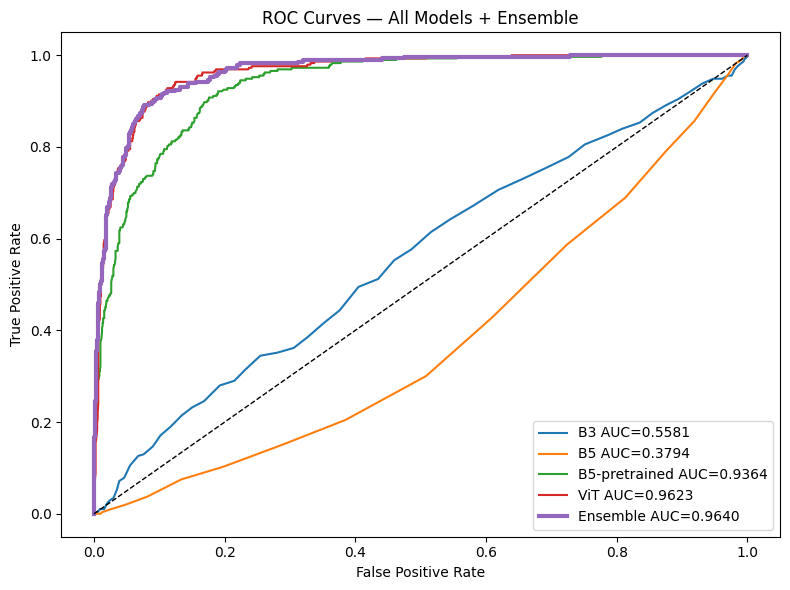

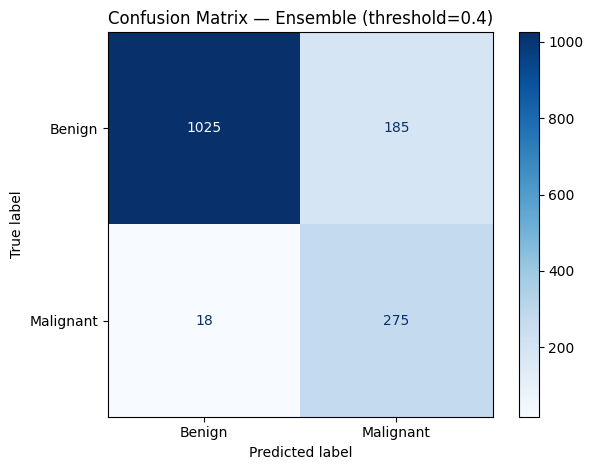

        Model      AUC   Recall       F1
           B3 0.558119 1.000000 0.326281
           B5 0.379401 1.000000 0.326281
B5-pretrained 0.936392 0.972696 0.574597
          ViT 0.962340 0.839590 0.801303
     Ensemble 0.964014 0.938567 0.730412

✓ All outputs saved.


In [16]:
# ROC curves — all models + ensemble
plt.figure(figsize=(8, 6))
for name, prob in [("B3", prob_b3), ("B5", prob_b5),
                   ("B5-pretrained", prob_b5p), ("ViT", prob_vit),
                   ("Ensemble", prob_ensemble)]:
    fpr, tpr, _ = roc_curve(y_test_true, prob)
    auc = roc_auc_score(y_test_true, prob)
    lw  = 3 if name == "Ensemble" else 1.5
    plt.plot(fpr, tpr, lw=lw, label=f"{name} AUC={auc:.4f}")

plt.plot([0,1],[0,1],"k--",lw=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models + Ensemble")
plt.legend(loc="lower right"); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_all_models.png", dpi=150); plt.show()

# Confusion matrix — ensemble
cm   = confusion_matrix(y_test_true, y_pred_ensemble)
disp = ConfusionMatrixDisplay(cm, display_labels=["Benign","Malignant"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — Ensemble (threshold={THRESHOLD})")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_ensemble.png", dpi=150); plt.show()

# Save results
results = pd.DataFrame({
    "Model":    ["B3","B5","B5-pretrained","ViT","Ensemble"],
    "AUC":      [roc_auc_score(y_test_true, p) for p in [prob_b3,prob_b5,prob_b5p,prob_vit,prob_ensemble]],
    "Recall":   [recall_score(y_test_true,(p>=THRESHOLD).astype(int),zero_division=0)
                 for p in [prob_b3,prob_b5,prob_b5p,prob_vit,prob_ensemble]],
    "F1":       [f1_score(y_test_true,(p>=THRESHOLD).astype(int),zero_division=0)
                 for p in [prob_b3,prob_b5,prob_b5p,prob_vit,prob_ensemble]],
})
results.to_csv(OUTPUT_DIR / "ensemble_results.csv", index=False)
print(results.to_string(index=False))

pd.DataFrame({
    "true_label": y_test_true,
    "predicted":  y_pred_ensemble,
    "prob_malignant": prob_ensemble
}).to_csv(OUTPUT_DIR / "ensemble_predictions.csv", index=False)

print("\n✓ All outputs saved.")

In [17]:
# Verify checkpoints loaded correctly
for name, model in [("B3", model_b3), ("B5", model_b5)]:
    auc, _, _, _ = eval_binary(model, val_loader)
    print(f"{name} val AUC: {auc:.4f}  (should be ~0.93+)")

B3 val AUC: 0.5674  (should be ~0.93+)
B5 val AUC: 0.4051  (should be ~0.93+)


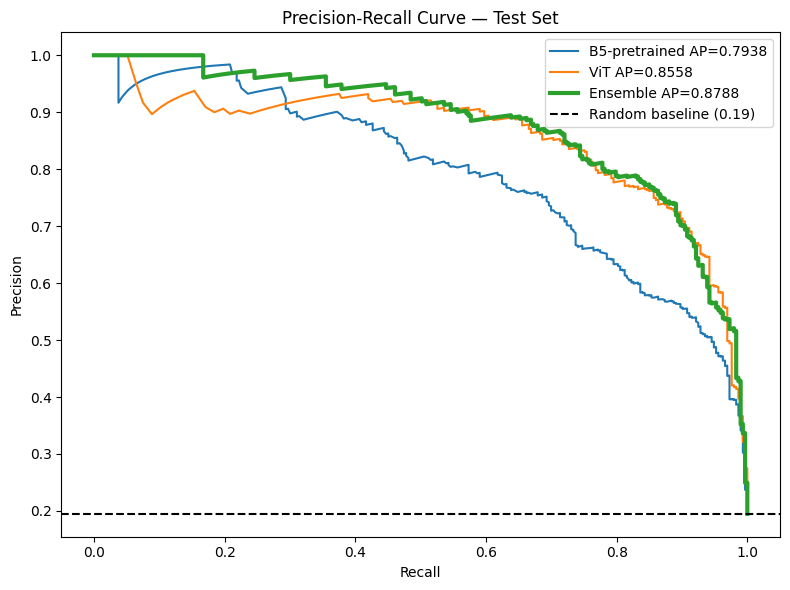

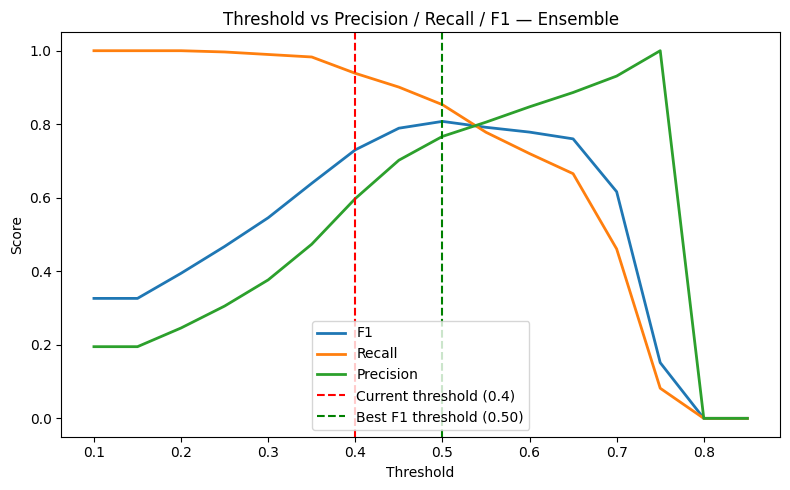

Best F1 threshold: 0.50 → F1: 0.8078


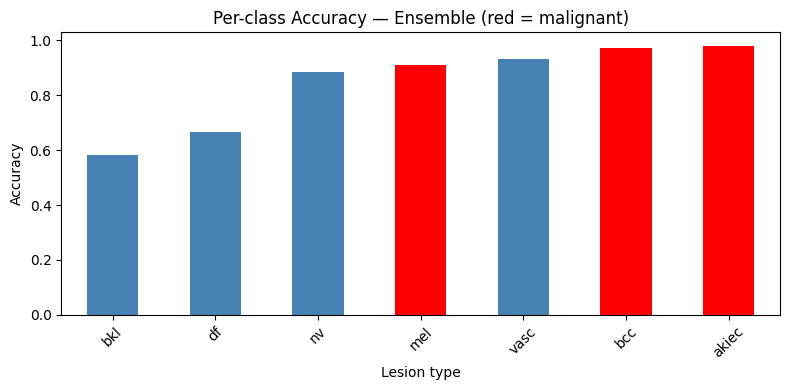

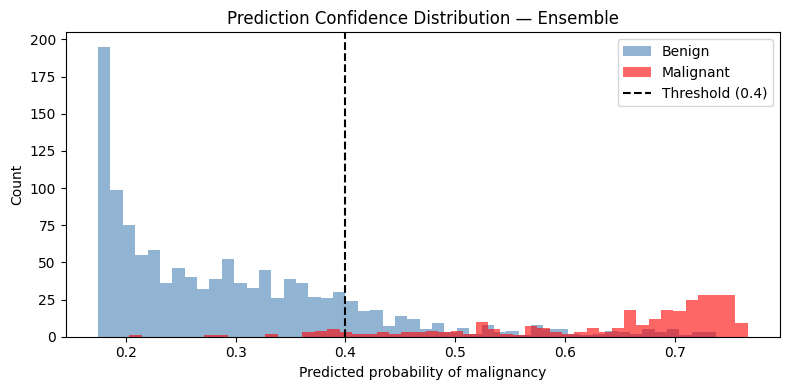

In [18]:
# ── 1. Precision-Recall Curve (better than ROC for imbalanced data)
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))
for name, prob in [("B5-pretrained", prob_b5p), ("ViT", prob_vit), ("Ensemble", prob_ensemble)]:
    prec, rec, _ = precision_recall_curve(y_test_true, prob)
    ap = average_precision_score(y_test_true, prob)
    lw = 3 if name == "Ensemble" else 1.5
    plt.plot(rec, prec, lw=lw, label=f"{name} AP={ap:.4f}")

baseline = y_test_true.sum() / len(y_test_true)
plt.axhline(baseline, color="k", linestyle="--", label=f"Random baseline ({baseline:.2f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Test Set")
plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "precision_recall_curve.png", dpi=150); plt.show()

# ── 2. Threshold vs F1/Recall tradeoff
thresholds = np.arange(0.1, 0.9, 0.05)
f1s, recalls, precisions = [], [], []
for t in thresholds:
    pred = (prob_ensemble >= t).astype(int)
    f1s.append(f1_score(y_test_true, pred, zero_division=0))
    recalls.append(recall_score(y_test_true, pred, zero_division=0))
    precisions.append(precision_score(y_test_true, pred, zero_division=0))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1s,        label="F1",        lw=2)
plt.plot(thresholds, recalls,    label="Recall",    lw=2)
plt.plot(thresholds, precisions, label="Precision", lw=2)
plt.axvline(THRESHOLD, color="red", linestyle="--", label=f"Current threshold ({THRESHOLD})")
best_t = thresholds[np.argmax(f1s)]
plt.axvline(best_t, color="green", linestyle="--", label=f"Best F1 threshold ({best_t:.2f})")
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.title("Threshold vs Precision / Recall / F1 — Ensemble")
plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "threshold_tradeoff.png", dpi=150); plt.show()
print(f"Best F1 threshold: {best_t:.2f} → F1: {max(f1s):.4f}")

# ── 3. Class-level breakdown — what lesion types does the model struggle with?
df_test = test_df.copy().reset_index(drop=True)
df_test["prob_malignant"] = prob_ensemble
df_test["predicted"]      = (prob_ensemble >= THRESHOLD).astype(int)
df_test["correct"]        = (df_test["predicted"] == df_test["target"]).astype(int)

acc_by_class = df_test.groupby("dx")["correct"].mean().sort_values()
plt.figure(figsize=(8, 4))
acc_by_class.plot(kind="bar", color=["red" if x in MALIGNANT else "steelblue" for x in acc_by_class.index])
plt.ylabel("Accuracy"); plt.xlabel("Lesion type")
plt.title("Per-class Accuracy — Ensemble (red = malignant)")
plt.xticks(rotation=45); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_class_accuracy.png", dpi=150); plt.show()

# ── 4. Confidence distribution — how confident is the model?
plt.figure(figsize=(8, 4))
plt.hist(prob_ensemble[y_test_true==0], bins=50, alpha=0.6, label="Benign",    color="steelblue")
plt.hist(prob_ensemble[y_test_true==1], bins=50, alpha=0.6, label="Malignant", color="red")
plt.axvline(THRESHOLD, color="black", linestyle="--", label=f"Threshold ({THRESHOLD})")
plt.xlabel("Predicted probability of malignancy")
plt.ylabel("Count")
plt.title("Prediction Confidence Distribution — Ensemble")
plt.legend(); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confidence_distribution.png", dpi=150); plt.show()